# COMPAS race-binary EXP4 CMAB fairness

This notebook runs the COMPAS experiments with binary race as the sensitive attribute for the EXP4 policy family.

The objective is to compare EXP4 and FairEXP4 under two preprocessing settings:

- **Uniform**: the training stream is sampled without group-label reweighting;
- **Reweighting**: group-label strata are reweighted before the online replay.

The notebook evaluates three levels of fairness intervention:

- **Pre-processing**: uniform sampling versus group-label reweighting;
- **In-processing**: EXP4 versus demographic-parity-aware FairEXP4;
- **Post-processing**: group-specific threshold calibration on held-out data.

The binary action is interpreted as the predicted recidivism class. The reward is equal to 1 when the selected action matches the observed label and 0 otherwise. Therefore, average reward is equivalent to accuracy in this offline classification-derived bandit setting.

The main utility metrics are average reward and cumulative prediction error. Fairness is assessed using Demographic Parity Gap, Equalized Odds Gap, and UtilityGap. Temporal figures report the evolution of these metrics over the learning horizon.


## Imports and configuration

This section loads the project modules, defines the run mode, output directories, random seeds, horizon, EXP4 hyperparameters, preprocessing settings, and post-processing settings.

For reproducibility, the notebook can either regenerate the full benchmark or reload cached outputs.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from scipy.stats import wilcoxon
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from fair_bandits.config import build_config
from fair_bandits.data.compas import (
    clean_compas_minimal,
    ensure_compas_race_binary,
    load_compas,
    prepare_compas_contextual,
)

from fair_bandits.metrics import summarize_classification_bandit

from fair_bandits.experiments import (
    train_expert_pool,
    run_trajectory,
    run_benchmark,
    run_exp4_postprocessing_horizon_benchmark,
)

from fair_bandits.plots.compas_exp4 import (
    horizontal_metric_plot,
    plot_cumulative_prediction_error_scale_diagnostic,
    plot_differential_cumulative_prediction_error,
    plot_exp4_postprocessing_over_horizon,
    plot_exp4_temporal_fairness,
    prepare_performance_plot_df,
    plot_utility_gap_over_time,
)

from fair_bandits.io import export_latex_table, fmt_mean_sd
from fair_bandits.experiments import run_exp4_postprocessing_horizon_benchmark

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)


In [2]:
summarize = summarize_classification_bandit

RUN_MODE = "full"
CFG = build_config("dev" if RUN_MODE == "dev" else "full")

RESULTS_ROOT = CFG.results_dir
OUTPUT_ROOT = RESULTS_ROOT / "compas_exp4_race_binary"
RUN_DIR = OUTPUT_ROOT / RUN_MODE
FIG_DIR = OUTPUT_ROOT / "final_figures"
TABLE_DIR = OUTPUT_ROOT / "overleaf_tables"

for directory in [RUN_DIR, FIG_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PREPROCESSINGS = ["uniform", "reweigh_group_label"]
POLICIES = ["EXP4", "FairEXP4"]
POSITIVE_CLASS = 1

if RUN_MODE == "dev":
    N_SEEDS = 2
    T_MAX = 1500
    LOG_EVERY = 25
    N_EXPERTS = 8
    EXPERT_BOOTSTRAP_SIZE = 4000
else:
    N_SEEDS = 50
    T_MAX = 30000
    LOG_EVERY = 50
    N_EXPERTS = 20
    EXPERT_BOOTSTRAP_SIZE = 8000

SEEDS = list(range(N_SEEDS))
TEST_SIZE = 0.20
CALIBRATION_SIZE_WITHIN_REMAINING = 0.20
EXP4_GAMMA = 0.07
EXP4_ETA = None
DP_TAU = 0.02
DP_LAMBDA = 2.0
BETA_SMOOTH = 1.0
MIN_GROUP_COUNT = 20
MAX_ACCURACY_DROP = 0.01
THRESHOLD_GRID_SIZE = 31
RUN_BENCHMARK = True
FORCE_RERUN = False
RANDOM_STATE = 42

TEMPORAL_PATH = RUN_DIR / "compas_race_binary_exp4_temporal.csv"
ENDPOINT_PATH = RUN_DIR / "compas_race_binary_exp4_endpoint.csv"
POSTPROC_PATH = RUN_DIR / "compas_race_binary_exp4_postprocessing.csv"
PARAMETERS_PATH = RUN_DIR / "compas_race_binary_exp4_postprocessing_parameters.csv"

print("RUN_MODE:", RUN_MODE)
print("RUN_DIR:", RUN_DIR)
print("N_SEEDS:", N_SEEDS)
print("T_MAX:", T_MAX)
print("LOG_EVERY:", LOG_EVERY)
print("N_EXPERTS:", N_EXPERTS)


RUN_MODE: full
RUN_DIR: results\full\compas_exp4_race_binary\full
N_SEEDS: 50
T_MAX: 30000
LOG_EVERY: 50
N_EXPERTS: 20


## Load and prepare COMPAS binary-race data

The COMPAS dataset is loaded and prepared with binary race as the sensitive attribute.

The original supervised dataset is transformed into an offline contextual bandit environment. At each round, the learner observes one individual context, selects a binary action, and receives reward 1 if the selected action matches the observed label.

In [3]:
df_raw = load_compas(cache_dir=CFG.cache_dir)
df_raw = clean_compas_minimal(df_raw)
df_raw = ensure_compas_race_binary(df_raw)

X, y, group, feature_names, meta = prepare_compas_contextual(
    df_raw,
    sensitive_col="race_binary",
)

compas_df = df_raw.copy()
X_df = pd.DataFrame(X, columns=feature_names)
y_series = pd.Series(y, name="target")
group_series = pd.Series(group, name="race_binary")

print("Shape after cleaning:", df_raw.shape)
print("Prepared X shape:", X.shape)
display(df_raw.head())

Shape after cleaning: (7214, 10)
Prepared X shape: (7214, 15)


,sex,race,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,two_year_recid,race_binary
0,Male,Other,69,0,0,0,0,F,0,Non-White
1,Male,African-American,34,0,0,0,0,F,1,Non-White
2,Male,African-American,24,0,0,1,4,F,1,Non-White
3,Male,African-American,23,0,1,0,1,F,0,Non-White
4,Male,Other,43,0,0,0,2,F,0,Non-White


## Split, standardize, and build expert advice

This section creates train, calibration, and test splits, standardizes the feature matrix, and trains the supervised expert pool required by EXP4.

The expert pool provides action-advice matrices used by EXP4 and FairEXP4 during the contextual bandit replay.

In [4]:
strata = (
    group_series.astype(str)
    + "||"
    + y_series.astype(str)
)

(
    X_train_df,
    X_test_df,
    y_train_s,
    y_test_s,
    g_train_s,
    g_test_s,
) = train_test_split(
    X_df,
    y_series,
    group_series,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=strata,
)

strata_remaining = (
    g_train_s.astype(str)
    + "||"
    + y_train_s.astype(str)
)

(
    X_train_df,
    X_cal_df,
    y_train_s,
    y_cal_s,
    g_train_s,
    g_cal_s,
) = train_test_split(
    X_train_df,
    y_train_s,
    g_train_s,
    test_size=CALIBRATION_SIZE_WITHIN_REMAINING,
    random_state=43,
    stratify=strata_remaining,
)

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train_df
)

X_cal = scaler.transform(
    X_cal_df
)

X_test = scaler.transform(
    X_test_df
)

y_train = y_train_s.to_numpy(
    dtype=int
)

y_cal = y_cal_s.to_numpy(
    dtype=int
)

y_test = y_test_s.to_numpy(
    dtype=int
)

g_train = g_train_s.astype(str).to_numpy()
g_cal = g_cal_s.astype(str).to_numpy()
g_test = g_test_s.astype(str).to_numpy()

print(
    "Train:",
    X_train.shape,
    "Calibration:",
    X_cal.shape,
    "Test:",
    X_test.shape,
)

print(
    "Groups:",
    sorted(
        np.unique(
            g_train
        )
    ),
)

Train: (4616, 15) Calibration: (1155, 15) Test: (1443, 15)
Groups: ['Non-White', 'White']


In [5]:
print("Training expert pool...")
expert_pool = train_expert_pool(
    X_train,
    y_train,
    n_experts=N_EXPERTS,
    bootstrap_size=EXPERT_BOOTSTRAP_SIZE,
    seed=2026,
)

print("Computing cached expert advice...")
ADVICE_TRAIN = expert_pool.predict_advice(X_train)
ADVICE_CAL = expert_pool.predict_advice(X_cal)
ADVICE_TEST = expert_pool.predict_advice(X_test)

print("ADVICE_TRAIN:", ADVICE_TRAIN.shape)
print("ADVICE_CAL:", ADVICE_CAL.shape)
print("ADVICE_TEST:", ADVICE_TEST.shape)


Training expert pool...
Computing cached expert advice...
ADVICE_TRAIN: (4616, 20, 2)
ADVICE_CAL: (1155, 20, 2)
ADVICE_TEST: (1443, 20, 2)


## Metrics, preprocessing, EXP4 and FairEXP4

This section defines the metric helpers, preprocessing logic, EXP4/FairEXP4 policies, and replay functions used in the COMPAS binary-race experiment.

The internal key `reweigh_group_label` is kept for compatibility with existing cached results, while figures and tables display it as Reweighting.

In [6]:
from fair_bandits.metrics import summarize_classification_bandit
summarize = summarize_classification_bandit

## Held-out scoring and post-processing

Post-processing is applied after training and uses group-specific thresholds calibrated on a held-out calibration set. It is reported as a final held-out comparison rather than as an online temporal learning curve.

In [7]:
POSTPROC_LONG_PATH = RUN_DIR / "compas_race_binary_exp4_postprocessing_long.csv"
POSTPROC_LONG_PARAMETERS_PATH = (RUN_DIR / "compas_race_binary_exp4_postprocessing_long_parameters.csv")

## Preflight

The preflight runs a short sanity check before launching or loading the full benchmark.

It verifies that EXP4 and FairEXP4 can process the expert-advice matrices, produce actions, update their internal weights, and output the expected temporal metrics.

In [8]:
print("Running preflight...")

for policy_name in POLICIES:
    preview, model = run_trajectory(
        seed=0,
        policy_name=policy_name,
        preprocessing="uniform",
        y_train=y_train,
        g_train=g_train,
        advice_train=ADVICE_TRAIN,
        t_max=min(500, T_MAX),
        log_every=100,
        n_experts=N_EXPERTS,
        exp4_gamma=EXP4_GAMMA,
        exp4_eta=EXP4_ETA,
        dp_lambda=DP_LAMBDA,
        dp_tau=DP_TAU,
        beta_smooth=BETA_SMOOTH,
        min_group_count=MIN_GROUP_COUNT,
    )

    print("\n", policy_name)
    display(preview.tail(1))

print("Preflight completed successfully.")


Running preflight...

 EXP4


,t,seed,policy,preprocessing,accuracy,average_reward,cumulative_prediction_error,cumulative_regret,DP_gap,TPR_gap,FPR_gap,EO_gap,UtilityGap
5,500,0,EXP4,uniform,0.616,0.616,192.0,192.0,0.137154,0.085165,0.165774,0.165774,0.003714



 FairEXP4


,t,seed,policy,preprocessing,accuracy,average_reward,cumulative_prediction_error,cumulative_regret,DP_gap,TPR_gap,FPR_gap,EO_gap,UtilityGap
5,500,0,FairEXP4,uniform,0.628,0.628,186.0,186.0,0.097977,0.027473,0.148824,0.148824,0.03062


Preflight completed successfully.


## Run or load COMPAS EXP4 benchmark

This section either runs the full COMPAS binary-race EXP4 benchmark or reloads cached outputs.

The benchmark evaluates EXP4 and FairEXP4 across both preprocessing settings, all random seeds, and the full learning horizon. The outputs are stored as temporal trajectories, endpoint summaries, post-processing results, and post-processing parameter tables.

In [9]:
if RUN_BENCHMARK:
    print("Launching main benchmark with run_benchmark()...")

    temporal_df, endpoint_df, postproc_df, parameters_df = run_benchmark(
    y_train=y_train,
    g_train=g_train,
    advice_train=ADVICE_TRAIN,
    y_cal=y_cal,
    g_cal=g_cal,
    advice_cal=ADVICE_CAL,
    y_test=y_test,
    g_test=g_test,
    advice_test=ADVICE_TEST,
    temporal_path=TEMPORAL_PATH,
    endpoint_path=ENDPOINT_PATH,
    postproc_path=POSTPROC_PATH,
    parameters_path=PARAMETERS_PATH,
    seeds=SEEDS,
    preprocessings=PREPROCESSINGS,
    policies=POLICIES,
    t_max=T_MAX,
    log_every=LOG_EVERY,
    n_experts=N_EXPERTS,
    exp4_gamma=EXP4_GAMMA,
    exp4_eta=EXP4_ETA,
    dp_lambda=DP_LAMBDA,
    dp_tau=DP_TAU,
    beta_smooth=BETA_SMOOTH,
    min_group_count=MIN_GROUP_COUNT,
    force_rerun=FORCE_RERUN,
    )

    print("\nBenchmark completed.")
    print("Written files:")
    print("TEMPORAL_PATH:  ", TEMPORAL_PATH, "exists =", TEMPORAL_PATH.exists())
    print("ENDPOINT_PATH:  ", ENDPOINT_PATH, "exists =", ENDPOINT_PATH.exists())
    print("POSTPROC_PATH:  ", POSTPROC_PATH, "exists =", POSTPROC_PATH.exists())
    print("PARAMETERS_PATH:", PARAMETERS_PATH, "exists =", PARAMETERS_PATH.exists())

    print("\nShapes:")
    print("temporal_df:  ", temporal_df.shape)
    print("endpoint_df:  ", endpoint_df.shape)
    print("postproc_df:  ", postproc_df.shape)
    print("parameters_df:", parameters_df.shape)

else:
    missing_files = [
        path
        for path in [
            TEMPORAL_PATH,
            ENDPOINT_PATH,
            POSTPROC_PATH,
            PARAMETERS_PATH,
        ]
        if not path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "Cached COMPAS EXP4 outputs are missing. "
            "Set RUN_BENCHMARK = True to generate them first. "
            f"Missing files: {missing_files}"
        )

    temporal_df = pd.read_csv(TEMPORAL_PATH)
    endpoint_df = pd.read_csv(ENDPOINT_PATH)
    postproc_df = pd.read_csv(POSTPROC_PATH)
    parameters_df = pd.read_csv(PARAMETERS_PATH)

    print("Loaded cached benchmark outputs.")
    print("temporal_df:  ", temporal_df.shape)
    print("endpoint_df:  ", endpoint_df.shape)
    print("postproc_df:  ", postproc_df.shape)
    print("parameters_df:", parameters_df.shape)


Launching main benchmark with run_benchmark()...
Cached: (0, 'uniform', 'EXP4')
Cached: (0, 'uniform', 'FairEXP4')
Cached PP: (0, 'uniform')
Cached: (0, 'reweigh_group_label', 'EXP4')
Cached: (0, 'reweigh_group_label', 'FairEXP4')
Cached PP: (0, 'reweigh_group_label')
Cached: (1, 'uniform', 'EXP4')
Cached: (1, 'uniform', 'FairEXP4')
Cached PP: (1, 'uniform')
Cached: (1, 'reweigh_group_label', 'EXP4')
Cached: (1, 'reweigh_group_label', 'FairEXP4')
Cached PP: (1, 'reweigh_group_label')
Cached: (2, 'uniform', 'EXP4')
Cached: (2, 'uniform', 'FairEXP4')
Cached PP: (2, 'uniform')
Cached: (2, 'reweigh_group_label', 'EXP4')
Cached: (2, 'reweigh_group_label', 'FairEXP4')
Cached PP: (2, 'reweigh_group_label')
Cached: (3, 'uniform', 'EXP4')
Cached: (3, 'uniform', 'FairEXP4')
Cached PP: (3, 'uniform')
Cached: (3, 'reweigh_group_label', 'EXP4')
Cached: (3, 'reweigh_group_label', 'FairEXP4')
Cached PP: (3, 'reweigh_group_label')
Cached: (4, 'uniform', 'EXP4')
Cached: (4, 'uniform', 'FairEXP4')
Cache

## Figures

This section generates the standard COMPAS binary-race EXP4 figure set.

The visual convention is consistent with the other notebooks: baseline policies are blue, fairness-aware policies are red, post-processed policies are green, uniform preprocessing is shown with solid lines, and reweighting with dotted lines.

Temporal bands indicate pointwise 95% confidence intervals for the mean trajectory across seeds.

In [10]:
print("Temporal:", temporal_df.shape if not temporal_df.empty else "MISSING/EMPTY")
print("Endpoint:", endpoint_df.shape if not endpoint_df.empty else "MISSING/EMPTY")
print("Postprocessing:", postproc_df.shape if not postproc_df.empty else "MISSING/EMPTY")

Temporal: (120200, 13)
Endpoint: (200, 13)
Postprocessing: (200, 13)


,policy,preprocessing,DP_gap_mean,DP_gap_std,EO_gap_mean,EO_gap_std,average_reward_mean,average_reward_std,accuracy_mean,accuracy_std,UtilityGap_mean,UtilityGap_std
0,FairEXP4,reweigh_group_label,0.173108,0.012290,0.221307,0.010303,0.668690,0.001083,0.668690,0.001083,0.028299,0.004661
1,FairEXP4,uniform,0.176303,0.011816,0.224239,0.010234,0.668621,0.001384,0.668621,0.001384,0.027577,0.004541
2,FairEXP4+PP,reweigh_group_label,0.087734,0.027685,0.144690,0.028777,0.666445,0.007387,0.666445,0.007387,0.046567,0.009326
3,FairEXP4+PP,uniform,0.084403,0.025168,0.141189,0.026577,0.666791,0.007467,0.666791,0.007467,0.046536,0.008821


Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_postprocessing_dp_gap.png


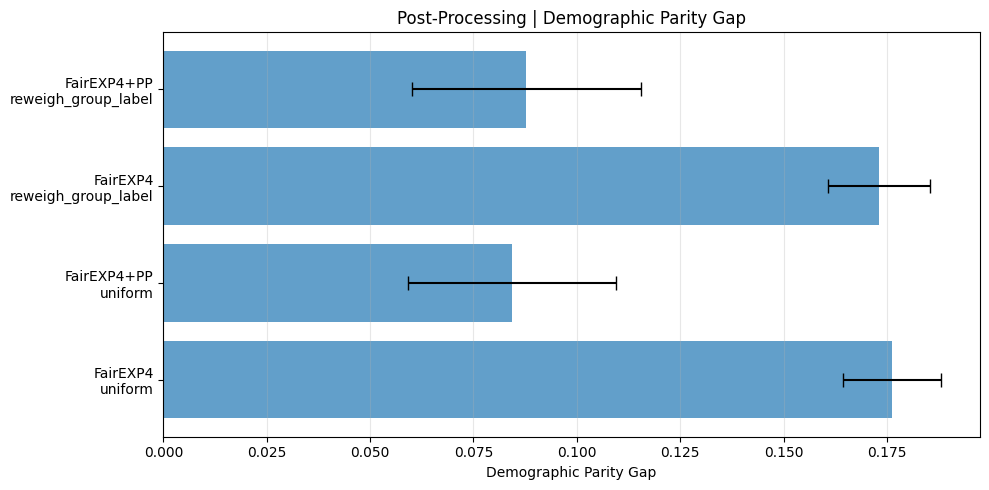

Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_postprocessing_eo_gap.png


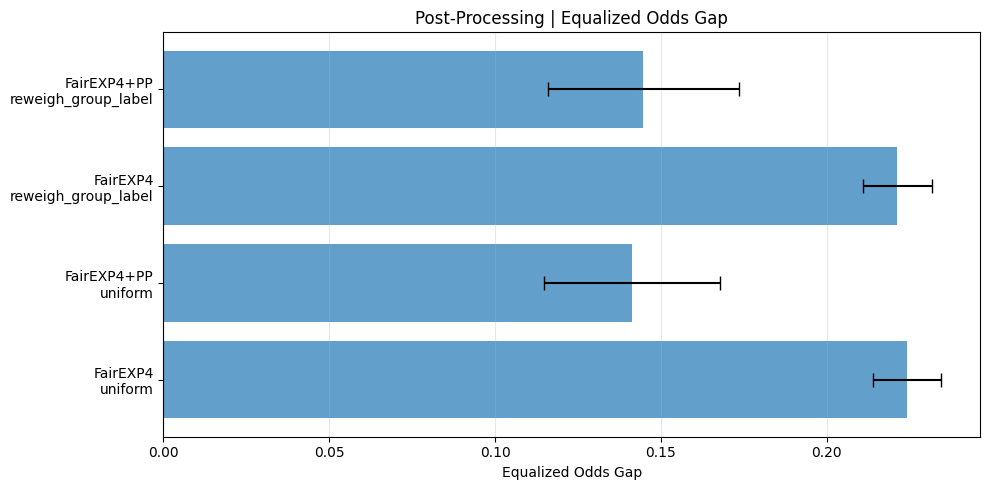

Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_postprocessing_accuracy.png


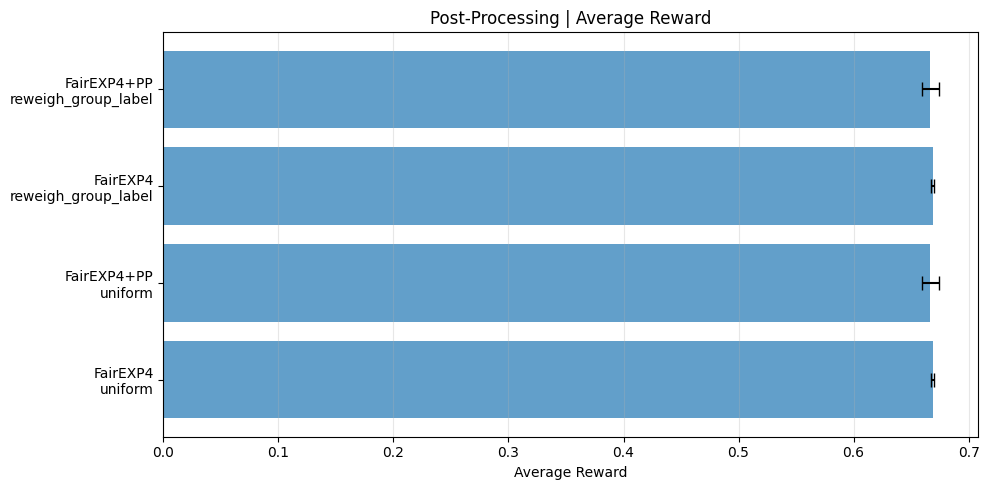

In [11]:
def add_exp4_online_baseline_to_postproc_long(
    *,
    postproc_long_df: pd.DataFrame,
    temporal_df: pd.DataFrame,
    horizons: list[int],
) -> pd.DataFrame:
    """
    Add EXP4 online baseline rows to the post-processing horizon table.
    """
    if postproc_long_df.empty:
        return postproc_long_df

    if "policy" in postproc_long_df.columns:
        if (postproc_long_df["policy"] == "EXP4").any():
            return postproc_long_df

    required_columns = {
        "seed",
        "policy",
        "preprocessing",
        "t",
    }

    missing_columns = required_columns - set(temporal_df.columns)

    if missing_columns:
        raise KeyError(
            f"Cannot add EXP4 baseline. Missing temporal columns: "
            f"{sorted(missing_columns)}"
        )

    dp_col = (
        "DP_gap"
        if "DP_gap" in temporal_df.columns
        else "DP_gap_over_time"
    )

    eo_col = (
        "EO_gap"
        if "EO_gap" in temporal_df.columns
        else "EO_gap_over_time"
    )

    exp4_temporal = temporal_df[
        temporal_df["policy"] == "EXP4"
    ].copy()

    rows = []

    for horizon in horizons:
        available = exp4_temporal[
            exp4_temporal["t"] <= int(horizon)
        ].copy()

        if available.empty:
            continue

        last_rows = (
            available
            .sort_values("t")
            .groupby(
                ["seed", "preprocessing"],
                as_index=False,
            )
            .tail(1)
        )

        for _, row in last_rows.iterrows():
            out = {
                "seed": int(row["seed"]),
                "policy": "EXP4",
                "preprocessing": str(row["preprocessing"]),
                "horizon": int(horizon),
                "DP_gap": float(row[dp_col]),
                "EO_gap": float(row[eo_col]),
            }

            if "average_reward" in row.index:
                out["average_reward"] = float(row["average_reward"])
            elif "avg_reward" in row.index:
                out["average_reward"] = float(row["avg_reward"])

            if "accuracy" in row.index:
                out["accuracy"] = float(row["accuracy"])
            elif "average_reward" in out:
                out["accuracy"] = out["average_reward"]

            if "UtilityGap" in row.index:
                out["UtilityGap"] = float(row["UtilityGap"])
            elif "UtilityGap_over_time" in row.index:
                out["UtilityGap"] = float(row["UtilityGap_over_time"])

            if "cumulative_prediction_error" in row.index:
                out["cumulative_prediction_error"] = float(
                    row["cumulative_prediction_error"]
                )

            rows.append(out)

    if not rows:
        print("No EXP4 rows could be reconstructed from temporal_df.")
        return postproc_long_df

    exp4_baseline_df = pd.DataFrame(rows)

    return pd.concat(
        [
            postproc_long_df,
            exp4_baseline_df,
        ],
        ignore_index=True,
    )

post_summary = (
    postproc_df
    .groupby(["policy", "preprocessing"], as_index=False)[
        ["DP_gap", "EO_gap", "average_reward", "accuracy", "UtilityGap"]
    ]
    .agg(["mean", "std"])
)

post_summary.columns = [
    "_".join(column).strip("_") for column in post_summary.columns
]

display(post_summary)

def plot_postprocessing_metric(metric: str, ylabel: str, filename: str):
    summary = (
        postproc_df
        .groupby(["policy", "preprocessing"], as_index=False)[metric]
        .agg(mean="mean", sd="std")
    )
    
    labels = []
    means = []
    errors = []
    
    order = [
        ("FairEXP4", "uniform"),
        ("FairEXP4+PP", "uniform"),
        ("FairEXP4", "reweigh_group_label"),
        ("FairEXP4+PP", "reweigh_group_label"),
    ]
    
    for policy, preprocessing in order:
        subset = summary[
            (summary["policy"] == policy) & (summary["preprocessing"] == preprocessing)
        ]
        if not subset.empty:
            labels.append(f"{policy}\n{preprocessing}")
            means.append(subset["mean"].values[0])
            errors.append(subset["sd"].values[0])
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(labels, means, xerr=errors, capsize=5, alpha=0.7)
    ax.set_xlabel(ylabel)
    ax.set_title(f"Post-Processing | {ylabel}")
    ax.grid(True, alpha=0.3, axis="x")
    
    plt.tight_layout()
    output_path = FIG_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print("Saved:", output_path)
    plt.show()

plot_postprocessing_metric("DP_gap", "Demographic Parity Gap", 
                          "compas_race_binary_exp4_postprocessing_dp_gap.png")
plot_postprocessing_metric("EO_gap", "Equalized Odds Gap",
                          "compas_race_binary_exp4_postprocessing_eo_gap.png")
plot_postprocessing_metric("average_reward", "Average Reward",
                          "compas_race_binary_exp4_postprocessing_accuracy.png")


Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_preprocessing_fairness.png


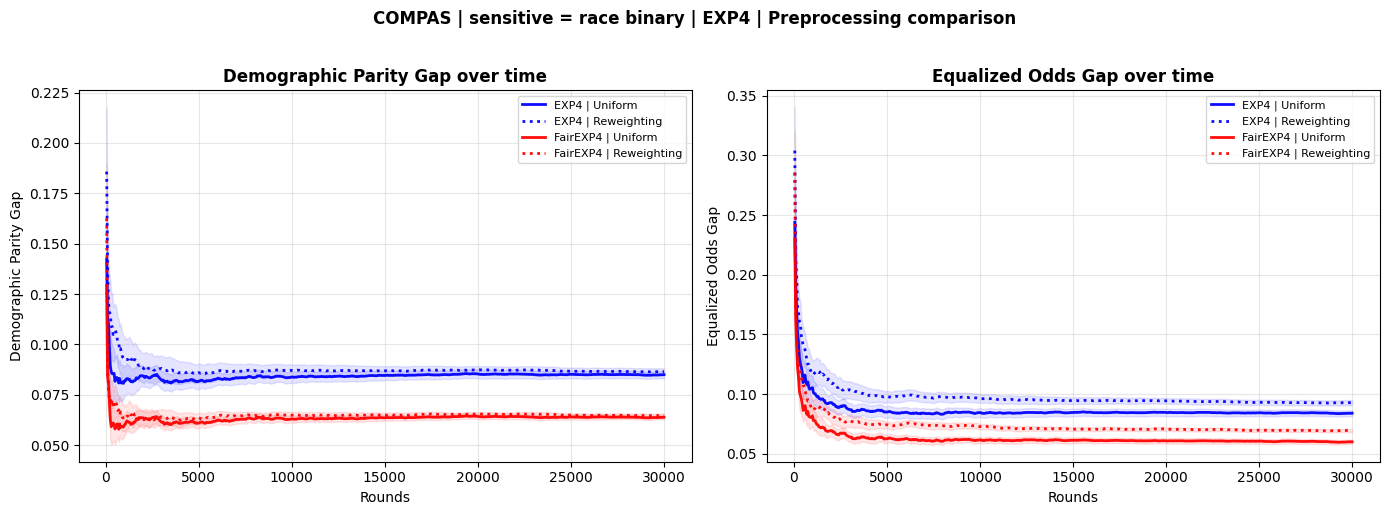

Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_inprocessing_fairness.png


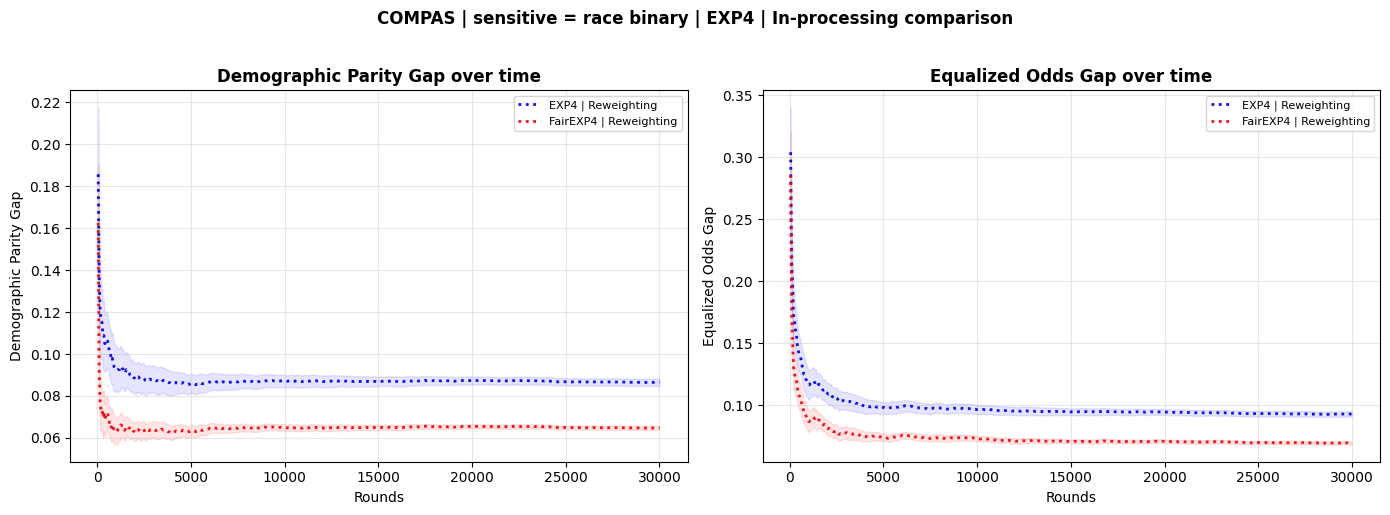

Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_utilitygap_over_time.png


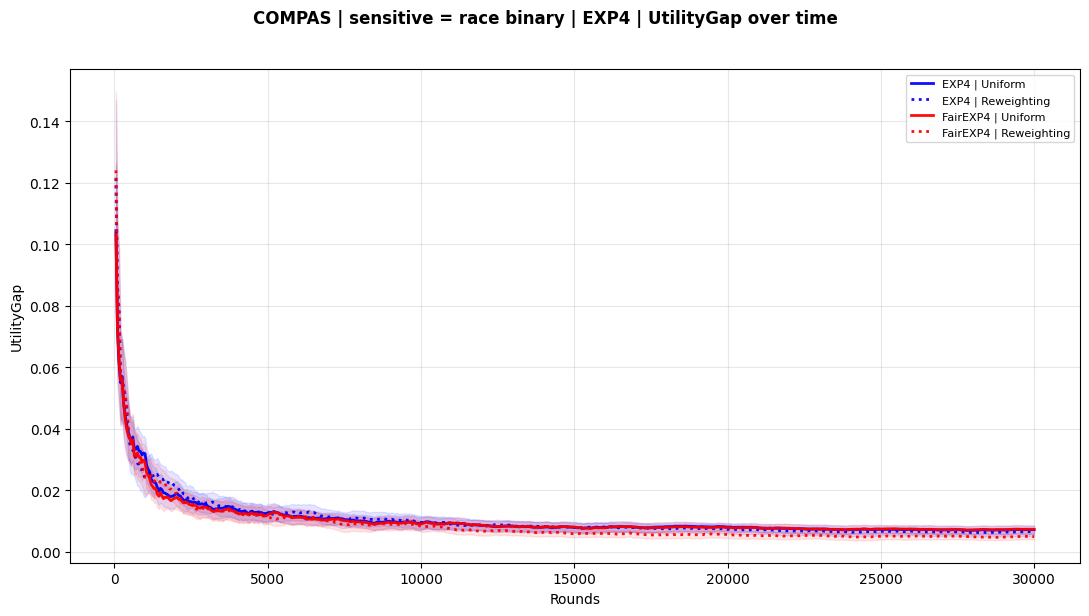

postproc_long_df is not available. Skipping post-processing-over-horizon plot.
Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_cumulative_prediction_error_scale_diagnostic.png


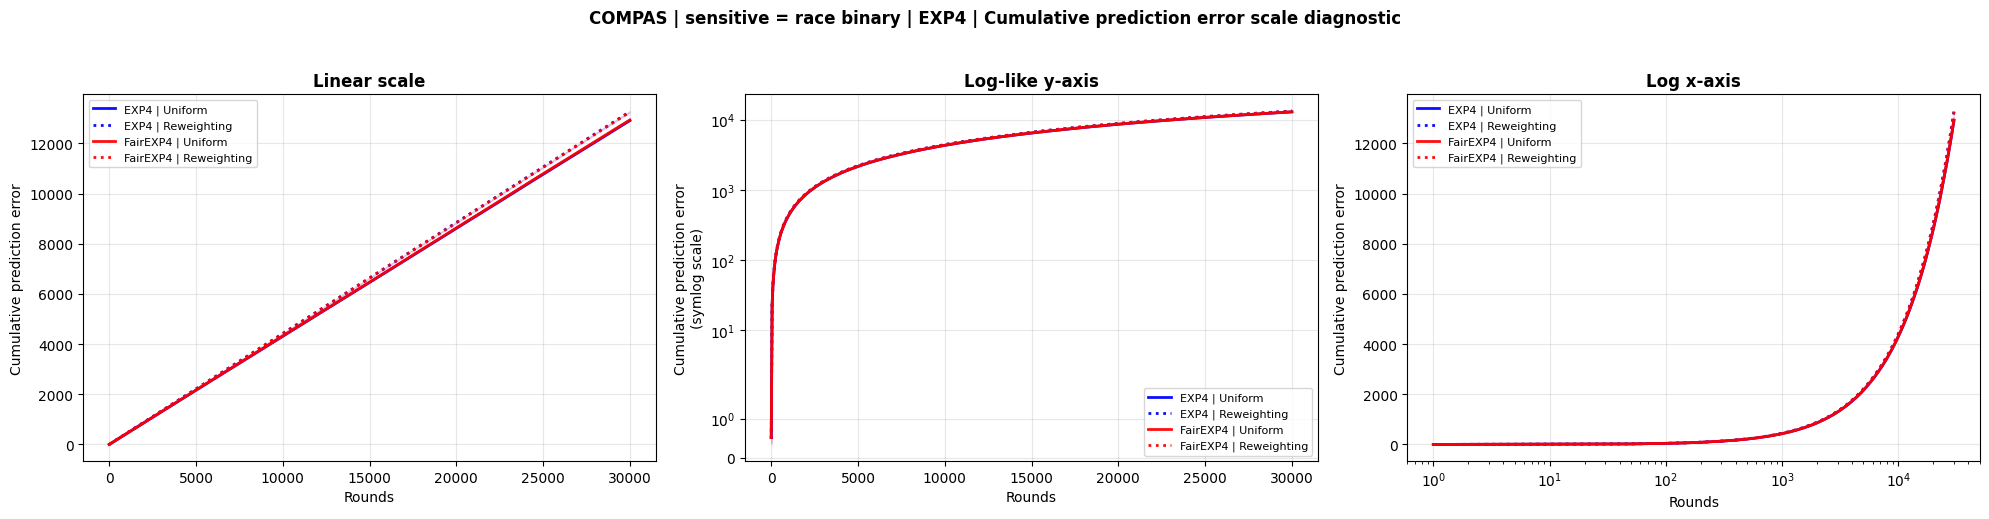

Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_differential_cumulative_prediction_error.png


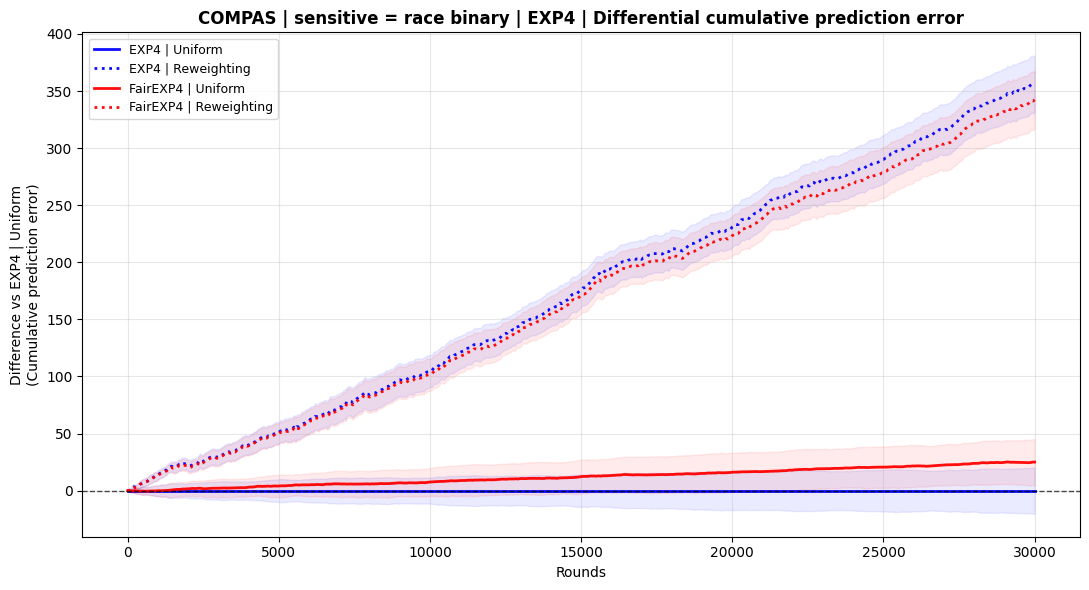

In [12]:
# Temporal fairness plots
if temporal_df.empty:
    print("temporal_df is empty. Run the main benchmark first.")
else:
    plot_exp4_temporal_fairness(
        temporal_df,
        fig_dir=FIG_DIR,
        policies=POLICIES,
        preprocessings=PREPROCESSINGS,
    )
if temporal_df.empty:
    print(
        "temporal_df is empty. "
        "Skipping UtilityGap plot."
    )
else:
    plot_utility_gap_over_time(
        temporal_df,
        fig_dir=FIG_DIR,
    )


# Post-processing-over-horizon plot
# This requires the separate longitudinal post-processing benchmark.
if "postproc_long_df" not in globals():
    if POSTPROC_LONG_PATH.exists():
        postproc_long_df = pd.read_csv(POSTPROC_LONG_PATH)
        print("Loaded postproc_long_df:", postproc_long_df.shape)
    else:
        postproc_long_df = pd.DataFrame()
        print(
            "postproc_long_df is not available. "
            "Skipping post-processing-over-horizon plot."
        )

if not postproc_long_df.empty:
    postproc_long_plot_df = add_exp4_online_baseline_to_postproc_long(
        postproc_long_df=postproc_long_df,
        temporal_df=temporal_df,
        horizons=POSTPROC_HORIZONS,
    )

    plot_exp4_postprocessing_over_horizon(
        postproc_long_plot_df,
        fig_dir=FIG_DIR,
    )


# Cumulative prediction error scale diagnostic
if temporal_df.empty:
    print("temporal_df is empty. Skipping cumulative prediction error diagnostic.")
else:
    plot_cumulative_prediction_error_scale_diagnostic(
        temporal_df,
        fig_dir=FIG_DIR,
    )


# Differential cumulative prediction error
if temporal_df.empty:
    print("temporal_df is empty. Skipping differential cumulative prediction error plot.")
else:
    plot_differential_cumulative_prediction_error(
        temporal_df,
        fig_dir=FIG_DIR,
    )

## Longitudinal post-processing curves

This section evaluates held-out post-processing metrics at multiple training horizons.

The objective is to show how post-processing performance changes as the online EXP4/FairEXP4 policy is trained for longer horizons.

In [13]:
POSTPROC_HORIZONS = [500, 1000, 2000, 5000, 10000, 15000, 20000, 25000, 30000]
POSTPROC_LONG_PATH = RUN_DIR / "compas_race_binary_exp4_postprocessing_perseed_long.csv"
POSTPROC_LONG_PARAMETERS_PATH = RUN_DIR / "compas_race_binary_exp4_postprocessing_parameters_long.csv"
RUN_POSTPROC_HORIZON_BENCHMARK = True

if RUN_POSTPROC_HORIZON_BENCHMARK:
    (
        postproc_long_df,
        postproc_long_parameters_df,
    ) = run_exp4_postprocessing_horizon_benchmark(
        y_train=y_train,
        g_train=g_train,
        advice_train=ADVICE_TRAIN,
        y_cal=y_cal,
        g_cal=g_cal,
        advice_cal=ADVICE_CAL,
        y_test=y_test,
        g_test=g_test,
        advice_test=ADVICE_TEST,
        postproc_long_path=POSTPROC_LONG_PATH,
        postproc_long_parameters_path=POSTPROC_LONG_PARAMETERS_PATH,
        seeds=SEEDS,
        preprocessings=PREPROCESSINGS,
        postproc_horizons=POSTPROC_HORIZONS,
        n_experts=N_EXPERTS,
        exp4_gamma=EXP4_GAMMA,
        exp4_eta=EXP4_ETA,
        dp_lambda=DP_LAMBDA,
        dp_tau=DP_TAU,
        beta_smooth=BETA_SMOOTH,
        min_group_count=MIN_GROUP_COUNT,
        force_rerun=FORCE_RERUN,
    )

    print(
        "\nLong post-processing results:",
        postproc_long_df.shape,
    )

else:
    print(
        "Set RUN_POSTPROC_HORIZON_BENCHMARK = True "
        "to generate the longitudinal post-processing curves."
    )

    if POSTPROC_LONG_PATH.exists():
        postproc_long_df = pd.read_csv(POSTPROC_LONG_PATH)
        print("Loaded existing postproc_long_df:", postproc_long_df.shape)
    else:
        postproc_long_df = pd.DataFrame()
        print("No existing postproc_long_df found.")

    if POSTPROC_LONG_PARAMETERS_PATH.exists():
        postproc_long_parameters_df = pd.read_csv(
            POSTPROC_LONG_PARAMETERS_PATH
        )
        print(
            "Loaded existing postproc_long_parameters_df:",
            postproc_long_parameters_df.shape,
        )
    else:
        postproc_long_parameters_df = pd.DataFrame()
        print("No existing postproc_long_parameters_df found.")



Training FairEXP4: (0, 'uniform')

Training FairEXP4: (0, 'reweigh_group_label')

Training FairEXP4: (1, 'uniform')

Training FairEXP4: (1, 'reweigh_group_label')

Training FairEXP4: (2, 'uniform')

Training FairEXP4: (2, 'reweigh_group_label')

Training FairEXP4: (3, 'uniform')

Training FairEXP4: (3, 'reweigh_group_label')

Training FairEXP4: (4, 'uniform')

Training FairEXP4: (4, 'reweigh_group_label')

Training FairEXP4: (5, 'uniform')

Training FairEXP4: (5, 'reweigh_group_label')

Training FairEXP4: (6, 'uniform')

Training FairEXP4: (6, 'reweigh_group_label')

Training FairEXP4: (7, 'uniform')

Training FairEXP4: (7, 'reweigh_group_label')

Training FairEXP4: (8, 'uniform')

Training FairEXP4: (8, 'reweigh_group_label')

Training FairEXP4: (9, 'uniform')

Training FairEXP4: (9, 'reweigh_group_label')

Training FairEXP4: (10, 'uniform')

Training FairEXP4: (10, 'reweigh_group_label')

Training FairEXP4: (11, 'uniform')

Training FairEXP4: (11, 'reweigh_group_label')

Training Fa

## Plot longitudinal post-processing curves


Loaded postproc_long_df: (1800, 13)
Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_postprocessing_over_horizon.png


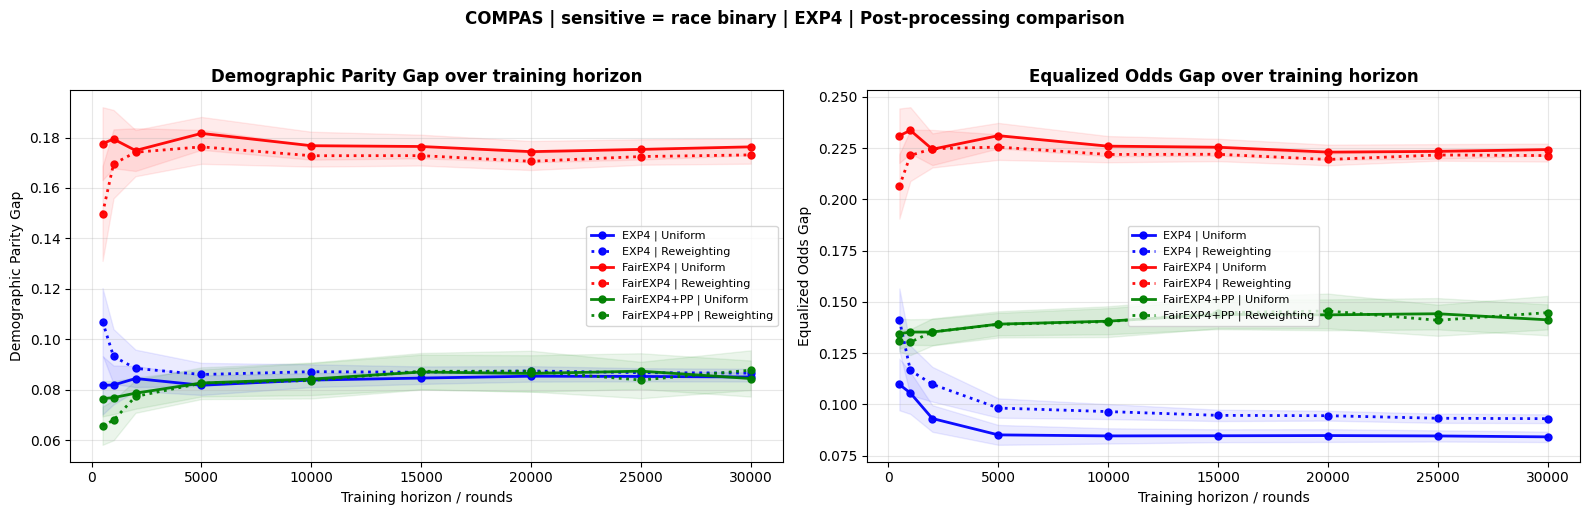

In [14]:
if not POSTPROC_LONG_PATH.exists():
    print(
        "The longitudinal post-processing file does not exist. "
        "Run the previous cell first with "
        "RUN_POSTPROC_HORIZON_BENCHMARK = True."
    )

    postproc_long_df = pd.DataFrame()

else:
    postproc_long_df = pd.read_csv(
        POSTPROC_LONG_PATH
    )

    print(
        "Loaded postproc_long_df:",
        postproc_long_df.shape,
    )

    postproc_long_plot_df = add_exp4_online_baseline_to_postproc_long(
        postproc_long_df=postproc_long_df,
        temporal_df=temporal_df,
        horizons=POSTPROC_HORIZONS,
    )

    plot_exp4_postprocessing_over_horizon(
        postproc_long_plot_df,
        fig_dir=FIG_DIR,
    )

## Final summary tables

This section exports compact final summary tables for the COMPAS binary-race EXP4 experiment.

Average reward, cumulative prediction error, and UtilityGap are used as the primary compact utility metrics. Fairness metrics are reported through Demographic Parity Gap and Equalized Odds Gap.

In [15]:
online_final = (
    endpoint_df
    .sort_values("t")
    .groupby(["seed", "policy", "preprocessing"], as_index=False)
    .tail(1)
    .copy()
)

heldout_postproc = postproc_df.copy()

performance_source = pd.concat(
    [
        online_final,
        heldout_postproc[heldout_postproc["policy"] == "FairEXP4+PP"],
    ],
    ignore_index=True,
)

metrics_for_table = [
    ("accuracy", "Accuracy"),
    ("average_reward", "Average Reward"),
    ("cumulative_prediction_error", "Cumulative prediction error"),
    ("DP_gap", "DP Gap"),
    ("EO_gap", "EO Gap"),
    ("UtilityGap", "UtilityGap"),
]

policy_order = {"EXP4": 0, "FairEXP4": 1, "FairEXP4+PP": 2}
preprocessing_order = {"uniform": 0, "reweigh_group_label": 1}

rows = []

for (policy, preprocessing), group_df in performance_source.groupby(["policy", "preprocessing"]):
    row = {
        "Policy": policy,
        "Preprocessing": "Uniform" if preprocessing == "uniform" else "Reweighting",
        "Seeds": int(group_df["seed"].nunique()),
    }
    
    for metric, label in metrics_for_table:
        row[label] = fmt_mean_sd(group_df[metric])
    
    row["_policy_order"] = policy_order.get(policy, 99)
    row["_preprocessing_order"] = preprocessing_order.get(preprocessing, 99)
    rows.append(row)

compas_race_binary_exp4_performance = (
    pd.DataFrame(rows)
    .sort_values(["_policy_order", "_preprocessing_order"])
    .drop(columns=["_policy_order", "_preprocessing_order"])
    .reset_index(drop=True)
)

display(compas_race_binary_exp4_performance)
performance_csv_path = TABLE_DIR / "compas_race_binary_exp4_performance_summary.csv"
performance_tex_path = TABLE_DIR / "compas_race_binary_exp4_performance_summary.tex"
compas_race_binary_exp4_performance.to_csv(performance_csv_path, index=False)

export_latex_table(
    compas_race_binary_exp4_performance,
    performance_tex_path,
    caption=(
        "Final performance summary for the COMPAS dataset using binary race as "
        "sensitive attribute and EXP4, including post-processing. "
        "Values are reported as mean $\\pm$ standard deviation across seeds."
    ),
    label="tab:compas_race_binary_exp4_performance_summary",
)

print("Saved:", performance_csv_path)
print("Saved:", performance_tex_path)

,Policy,Preprocessing,Seeds,Accuracy,Average Reward,Cumulative prediction error,DP Gap,EO Gap,UtilityGap
0,EXP4,Uniform,50,0.5696 $\pm$ 0.0024,0.5696 $\pm$ 0.0024,12912.7200 $\pm$ 71.2830,0.0850 $\pm$ 0.0063,0.0841 $\pm$ 0.0089,0.0071 $\pm$ 0.0047
1,EXP4,Reweighting,50,0.5577 $\pm$ 0.0029,0.5577 $\pm$ 0.0029,13269.1200 $\pm$ 87.6239,0.0866 $\pm$ 0.0060,0.0930 $\pm$ 0.0076,0.0065 $\pm$ 0.0050
2,FairEXP4,Uniform,50,0.5687 $\pm$ 0.0024,0.5687 $\pm$ 0.0024,12937.7600 $\pm$ 70.8564,0.0639 $\pm$ 0.0038,0.0602 $\pm$ 0.0068,0.0073 $\pm$ 0.0046
3,FairEXP4,Reweighting,50,0.5582 $\pm$ 0.0030,0.5582 $\pm$ 0.0030,13255.0600 $\pm$ 89.6436,0.0648 $\pm$ 0.0035,0.0696 $\pm$ 0.0047,0.0049 $\pm$ 0.0031
4,FairEXP4+PP,Uniform,50,0.6668 $\pm$ 0.0075,0.6668 $\pm$ 0.0075,480.8200 $\pm$ 10.7754,0.0844 $\pm$ 0.0252,0.1412 $\pm$ 0.0266,0.0465 $\pm$ 0.0088
5,FairEXP4+PP,Reweighting,50,0.6664 $\pm$ 0.0074,0.6664 $\pm$ 0.0074,481.3200 $\pm$ 10.6588,0.0877 $\pm$ 0.0277,0.1447 $\pm$ 0.0288,0.0466 $\pm$ 0.0093


Saved: results\full\compas_exp4_race_binary\overleaf_tables\compas_race_binary_exp4_performance_summary.csv
Saved: results\full\compas_exp4_race_binary\overleaf_tables\compas_race_binary_exp4_performance_summary.tex


## Final performance dot plots

Horizontal dot plots make the final performance table easier to read.

Points are means across seeds and horizontal error bars indicate 95% confidence intervals for the mean.

## Paired significance tests

This section performs paired Wilcoxon signed-rank tests across seeds.

The comparisons cover three intervention levels:

- preprocessing: EXP4 under uniform sampling versus reweighting;
- in-processing: EXP4 versus FairEXP4;
- post-processing: FairEXP4 versus FairEXP4+PP.

Online comparisons are evaluated at the final online endpoint. Post-processing comparisons are evaluated on the held-out test set. Holm correction is applied for multiple comparisons.


Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_predictive_accuracy_reward_summary.png


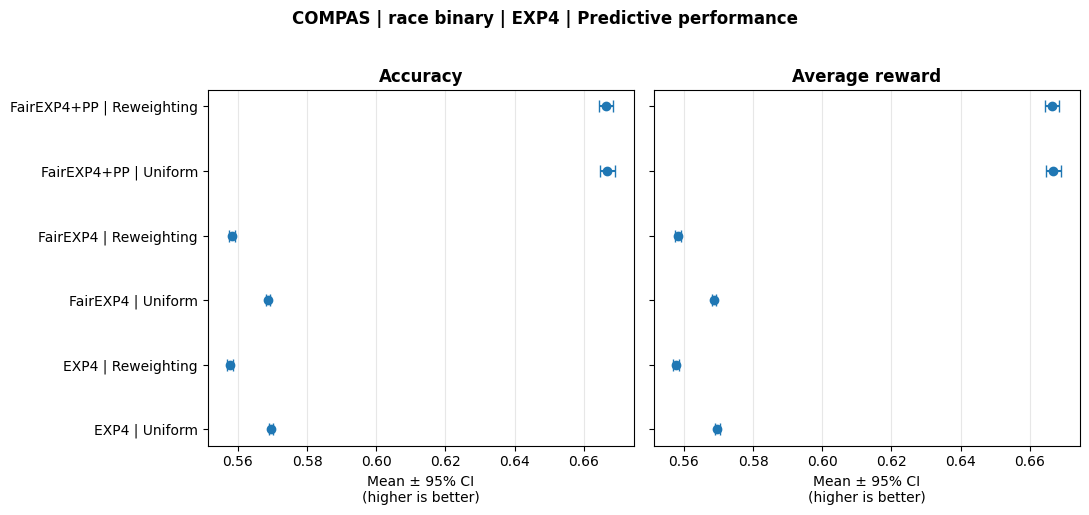

Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_cumulative_prediction_error_summary.png


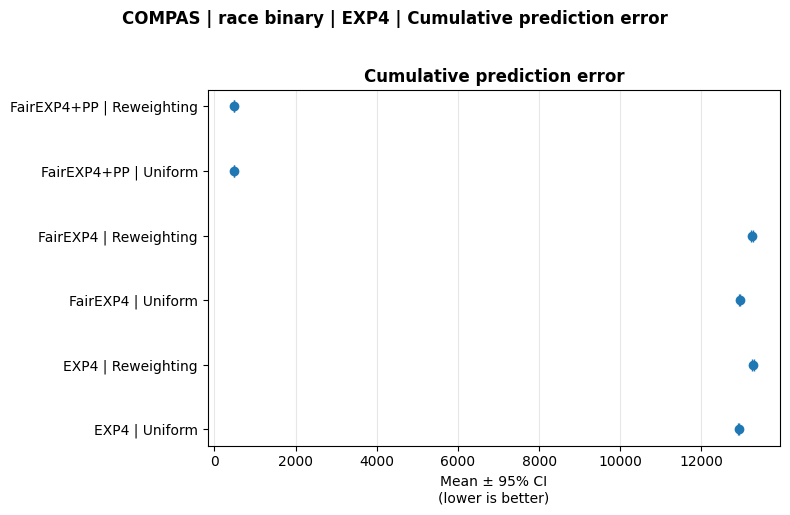

Saved: results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_fairness_summary.png


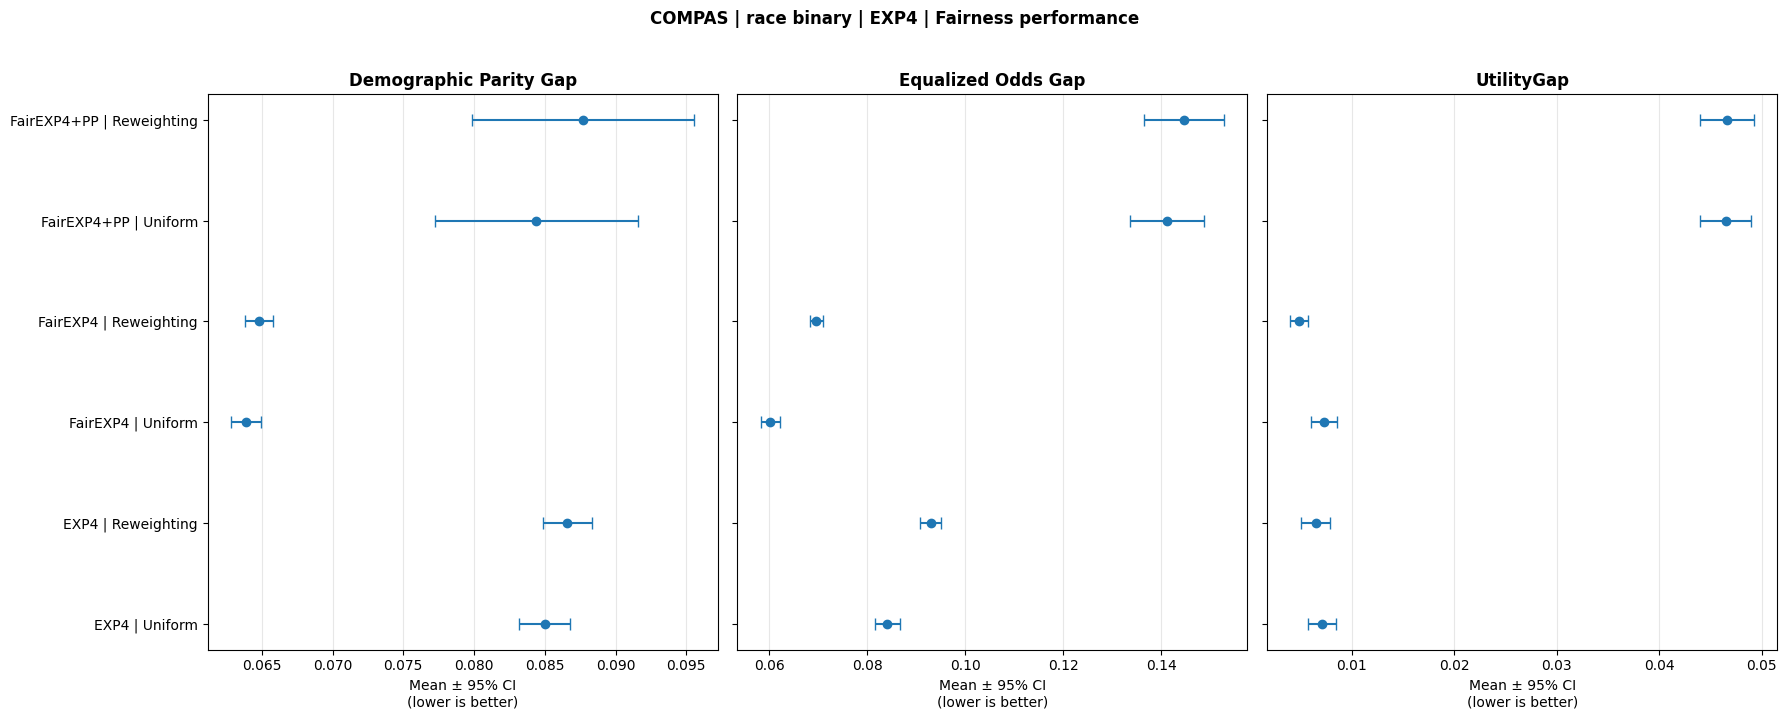

In [16]:
performance_plot_df = prepare_performance_plot_df(
    compas_race_binary_exp4_performance
)

method_order = [
    "EXP4 | Uniform",
    "EXP4 | Reweighting",
    "FairEXP4 | Uniform",
    "FairEXP4 | Reweighting",
    "FairEXP4+PP | Uniform",
    "FairEXP4+PP | Reweighting",
]

horizontal_metric_plot(
    performance_plot_df,
    metrics=[
        "Accuracy",
        "Average reward",
    ],
    title="COMPAS | race binary | EXP4 | Predictive performance",
    save_path=FIG_DIR / "compas_race_binary_exp4_predictive_accuracy_reward_summary.png",
    method_order=method_order,
    figsize=(11, 5),
)

horizontal_metric_plot(
    performance_plot_df,
    metrics=[
        "Cumulative prediction error",
    ],
    title="COMPAS | race binary | EXP4 | Cumulative prediction error",
    save_path=FIG_DIR / "compas_race_binary_exp4_cumulative_prediction_error_summary.png",
    method_order=method_order,
    figsize=(8, 5),
)

horizontal_metric_plot(
    performance_plot_df,
    metrics=[
        "DP gap",
        "EO gap",
        "UtilityGap",
    ],
    title="COMPAS | race binary | EXP4 | Fairness performance",
    save_path=FIG_DIR / "compas_race_binary_exp4_fairness_summary.png",
    method_order=method_order,
    figsize=(18, 7),
)

In [17]:
def safe_wilcoxon(
    baseline,
    intervention,
) -> float:
    baseline = np.asarray(
        baseline,
        dtype=float,
    )

    intervention = np.asarray(
        intervention,
        dtype=float,
    )

    mask = (
        np.isfinite(baseline)
        & np.isfinite(intervention)
    )

    baseline = baseline[mask]
    intervention = intervention[mask]

    if len(baseline) == 0:
        return np.nan

    if np.allclose(
        baseline,
        intervention,
    ):
        return 1.0

    return float(
        wilcoxon(
            baseline,
            intervention,
            alternative="two-sided",
            zero_method="wilcox",
            method="auto",
        ).pvalue
    )


def holm_adjust(
    p_values,
) -> np.ndarray:
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    p_values = np.where(
        np.isfinite(p_values),
        p_values,
        1.0,
    )

    order = np.argsort(p_values)

    adjusted = np.empty(
        len(p_values),
        dtype=float,
    )

    previous = 0.0

    for rank, index in enumerate(order):
        value = (
            len(p_values)
            - rank
        ) * p_values[index]

        value = min(
            max(
                value,
                previous,
            ),
            1.0,
        )

        adjusted[index] = value
        previous = value

    return adjusted


def format_p_value(
    p_value,
) -> str:
    if not np.isfinite(p_value):
        return "--"

    if p_value < 0.001:
        return "<0.001"

    return f"{p_value:.3f}"


def format_significance(
    p_value,
) -> str:
    if not np.isfinite(p_value):
        return ""

    return "*" if p_value < 0.05 else ""


def ensure_cumulative_prediction_error(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    df = dataframe.copy()

    if (
        "cumulative_prediction_error" not in df.columns
        and "cumulative_regret" in df.columns
    ):
        df["cumulative_prediction_error"] = df["cumulative_regret"]

    return df


online_final_stats = ensure_cumulative_prediction_error(
    online_final
)

heldout_postproc_stats = ensure_cumulative_prediction_error(
    heldout_postproc
)


online_metrics = [
    (
        "DP_gap",
        "DP gap",
    ),
    (
        "EO_gap",
        "EO gap",
    ),
    (
        "UtilityGap",
        "UtilityGap",
    ),
    (
        "average_reward",
        "Average reward",
    ),
    (
        "cumulative_prediction_error",
        "Cumulative prediction error",
    ),
]


heldout_metrics = [
    (
        "DP_gap",
        "DP gap",
    ),
    (
        "EO_gap",
        "EO gap",
    ),
    (
        "UtilityGap",
        "UtilityGap",
    ),
    (
        "average_reward",
        "Average reward",
    ),
]


comparisons = [
    (
        "Preprocessing effect",
        "online",
        "EXP4",
        "uniform",
        "EXP4",
        "reweigh_group_label",
        "EXP4 | Uniform",
        "EXP4 | Reweighting",
    ),
    (
        "Preprocessing effect",
        "online",
        "FairEXP4",
        "uniform",
        "FairEXP4",
        "reweigh_group_label",
        "FairEXP4 | Uniform",
        "FairEXP4 | Reweighting",
    ),
    (
        "In-processing effect",
        "online",
        "EXP4",
        "uniform",
        "FairEXP4",
        "uniform",
        "EXP4 | Uniform",
        "FairEXP4 | Uniform",
    ),
    (
        "In-processing effect",
        "online",
        "EXP4",
        "reweigh_group_label",
        "FairEXP4",
        "reweigh_group_label",
        "EXP4 | Reweighting",
        "FairEXP4 | Reweighting",
    ),
    (
        "Post-processing effect",
        "heldout",
        "FairEXP4",
        "uniform",
        "FairEXP4+PP",
        "uniform",
        "FairEXP4 | Uniform",
        "FairEXP4+PP | Uniform",
    ),
    (
        "Post-processing effect",
        "heldout",
        "FairEXP4",
        "reweigh_group_label",
        "FairEXP4+PP",
        "reweigh_group_label",
        "FairEXP4 | Reweighting",
        "FairEXP4+PP | Reweighting",
    ),
]


rows = []

for (
    comparison,
    source_name,
    baseline_policy,
    baseline_preprocessing,
    intervention_policy,
    intervention_preprocessing,
    baseline_label,
    intervention_label,
) in comparisons:
    source_df = (
        online_final_stats
        if source_name == "online"
        else heldout_postproc_stats
    )

    metrics = (
        online_metrics
        if source_name == "online"
        else heldout_metrics
    )

    for metric, metric_label in metrics:
        if metric not in source_df.columns:
            print(
                "Skipping missing metric:",
                metric,
            )
            continue

        baseline = (
            source_df[
                (
                    source_df["policy"]
                    == baseline_policy
                )
                & (
                    source_df["preprocessing"]
                    == baseline_preprocessing
                )
            ][
                [
                    "seed",
                    metric,
                ]
            ]
            .rename(
                columns={
                    metric: "baseline_value",
                }
            )
        )

        intervention = (
            source_df[
                (
                    source_df["policy"]
                    == intervention_policy
                )
                & (
                    source_df["preprocessing"]
                    == intervention_preprocessing
                )
            ][
                [
                    "seed",
                    metric,
                ]
            ]
            .rename(
                columns={
                    metric: "intervention_value",
                }
            )
        )

        paired = baseline.merge(
            intervention,
            on="seed",
            how="inner",
            validate="one_to_one",
        )

        if paired.empty:
            print(
                "Skipping empty paired comparison:",
                comparison,
                metric_label,
                baseline_label,
                intervention_label,
            )
            continue

        raw_p = safe_wilcoxon(
            paired["baseline_value"],
            paired["intervention_value"],
        )

        rows.append(
            {
                "Comparison": comparison,
                "Metric": metric_label,
                "Baseline": baseline_label,
                "Intervention": intervention_label,
                "Baseline value": fmt_mean_sd(
                    paired["baseline_value"]
                ),
                "Intervention value": fmt_mean_sd(
                    paired["intervention_value"]
                ),
                "p_raw": raw_p,
                "n_pairs": int(
                    paired["seed"].nunique()
                ),
            }
        )


compas_race_binary_exp4_significance_detailed = pd.DataFrame(
    rows
)

compas_race_binary_exp4_significance_detailed[
    "p_holm"
] = holm_adjust(
    compas_race_binary_exp4_significance_detailed[
        "p_raw"
    ]
)

compas_race_binary_exp4_significance_detailed[
    "Holm p"
] = compas_race_binary_exp4_significance_detailed[
    "p_holm"
].map(
    format_p_value
)

compas_race_binary_exp4_significance_detailed[
    "Sig."
] = compas_race_binary_exp4_significance_detailed[
    "p_holm"
].map(
    format_significance
)

compas_race_binary_exp4_significance = compas_race_binary_exp4_significance_detailed[
    [
        "Comparison",
        "Metric",
        "Baseline",
        "Intervention",
        "Baseline value",
        "Intervention value",
        "Holm p",
        "Sig.",
    ]
].copy()

display(
    compas_race_binary_exp4_significance
)


detailed_csv_path = (
    TABLE_DIR
    / "compas_race_binary_exp4_significance_tests_detailed.csv"
)

compact_csv_path = (
    TABLE_DIR
    / "compas_race_binary_exp4_significance_tests.csv"
)

compact_tex_path = (
    TABLE_DIR
    / "compas_race_binary_exp4_significance_tests.tex"
)

compas_race_binary_exp4_significance_detailed.to_csv(
    detailed_csv_path,
    index=False,
)

compas_race_binary_exp4_significance.to_csv(
    compact_csv_path,
    index=False,
)

export_latex_table(
    compas_race_binary_exp4_significance,
    compact_tex_path,
    caption=(
        "Holm-corrected paired Wilcoxon signed-rank tests across seeds for the "
        "COMPAS race-binary EXP4 experiment. Online comparisons are evaluated at "
        "the final online endpoint. Post-processing comparisons are evaluated on "
        "the held-out test set."
    ),
    label="tab:compas_race_binary_exp4_significance_tests",
)

print(
    "Saved:",
    detailed_csv_path,
)

print(
    "Saved:",
    compact_csv_path,
)

print(
    "Saved:",
    compact_tex_path,
)

,Comparison,Metric,Baseline,Intervention,Baseline value,Intervention value,Holm p,Sig.
0,Preprocessing effect,DP gap,EXP4 | Uniform,EXP4 | Reweighting,0.0850 $\pm$ 0.0063,0.0866 $\pm$ 0.0060,0.652,
1,Preprocessing effect,EO gap,EXP4 | Uniform,EXP4 | Reweighting,0.0841 $\pm$ 0.0089,0.0930 $\pm$ 0.0076,<0.001,*
2,Preprocessing effect,UtilityGap,EXP4 | Uniform,EXP4 | Reweighting,0.0071 $\pm$ 0.0047,0.0065 $\pm$ 0.0050,1.000,
3,Preprocessing effect,Average reward,EXP4 | Uniform,EXP4 | Reweighting,0.5696 $\pm$ 0.0024,0.5577 $\pm$ 0.0029,<0.001,*
4,Preprocessing effect,Cumulative prediction error,EXP4 | Uniform,EXP4 | Reweighting,12912.7200 $\pm$ 71.2830,13269.1200 $\pm$ 87.6239,<0.001,*
5,Preprocessing effect,DP gap,FairEXP4 | Uniform,FairEXP4 | Reweighting,0.0639 $\pm$ 0.0038,0.0648 $\pm$ 0.0035,0.652,
6,Preprocessing effect,EO gap,FairEXP4 | Uniform,FairEXP4 | Reweighting,0.0602 $\pm$ 0.0068,0.0696 $\pm$ 0.0047,<0.001,*
7,Preprocessing effect,UtilityGap,FairEXP4 | Uniform,FairEXP4 | Reweighting,0.0073 $\pm$ 0.0046,0.0049 $\pm$ 0.0031,0.053,
8,Preprocessing effect,Average reward,FairEXP4 | Uniform,FairEXP4 | Reweighting,0.5687 $\pm$ 0.0024,0.5582 $\pm$ 0.0030,<0.001,*
9,Preprocessing effect,Cumulative prediction error,FairEXP4 | Uniform,FairEXP4 | Reweighting,12937.7600 $\pm$ 70.8564,13255.0600 $\pm$ 89.6436,<0.001,*


Saved: results\full\compas_exp4_race_binary\overleaf_tables\compas_race_binary_exp4_significance_tests_detailed.csv
Saved: results\full\compas_exp4_race_binary\overleaf_tables\compas_race_binary_exp4_significance_tests.csv
Saved: results\full\compas_exp4_race_binary\overleaf_tables\compas_race_binary_exp4_significance_tests.tex


## Generated artifacts

This final section lists the figures, LaTeX/CSV tables, and raw cached outputs generated by the notebook.

In [18]:
print("FIGURES")
for path in sorted(FIG_DIR.glob("*.png")):
    print(path)

print("\nTABLES")
for path in sorted(TABLE_DIR.glob("*")):
    print(path)

print("\nRAW OUTPUTS")
for path in sorted(RUN_DIR.glob("*.csv")):
    print(path)

FIGURES
results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_cumulative_prediction_error_scale_diagnostic.png
results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_cumulative_prediction_error_summary.png
results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_cumulative_regret_scale_diagnostic.png
results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_differential_cumulative_prediction_error.png
results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_fairness_summary.png
results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_inprocessing_fairness.png
results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_postprocessing_accuracy.png
results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_postprocessing_dp_gap.png
results\full\compas_exp4_race_binary\final_figures\compas_race_binary_exp4_postprocessing_eo_gap.png
results\full\comp